In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. Load CSV ----
file_path = "Trees.csv"  # change to your file
df = pd.read_csv(file_path)

# # ---- 2. Basic dataset overview ----
print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

# print("\nFirst few rows:")
# print(df.head())

# print("\nData types:")
# print(df.dtypes)


Dataset shape:
(55676, 61)

Column names:
Index(['OBJECTID', 'ASSET_ID', 'SITE_NAME', 'PLOT_NO', 'FEATURE_ID',
       'LOCATION', 'TYPE', 'PRIM_MEAS', 'UNIT', 'SITE_CODE', 'FEAT_GP', 'X',
       'Y', 'DEAD', 'CLASSIFICATION', 'EXTENT_EASTING_1', 'EXTENT_NORTHING_1',
       'EXTENT_EASTING_2', 'EXTENT_NORTHING_2', 'LAYERS', 'LATIN_CODE',
       'LATIN_NAME', 'FEATURE_TYPE_NAME', 'COMMON_NAME', 'FULL_COMMON_NAME',
       'CROWN_HEIGHT', 'CROWN_WIDTH', 'CROWN_AREA', 'DBH',
       'LOCATION_RISK_ZONE', 'EPICORMIC', 'INSURANCE_CLAIM_HISTORY',
       'CENTRAL_ASSET_ID', 'CONTRACT_AREA_NAME', 'CUSTOMER', 'DEAD_FLAG',
       'FEATURE_GROUP', 'FEATURE_GROUP_CODE', 'FEATURETYPECODE', 'NOTES',
       'REVISION_NO', 'TREE_SPECIES', 'TREE_MODIFIED_RISK',
       'CANOPY_SIZE_AT_MATURITY', 'SPONSORSHIP', 'SPONSORSHIP_PACKAGE',
       'PLANTING_SEASON', 'PLANTING_FUNDER', 'PLANTING_NOTES', 'SPECIES_NOTES',
       'TREE_TYPE', 'JOBS_REQUIRED', 'SERVICES_VISIBILITY', 'CONSTRAINTS',
       'CANCELLATION

In [32]:
cols = ["OBJECTID", "SITE_NAME", "X", "Y", "EXTENT_EASTING_1", "EXTENT_NORTHING_1", "EXTENT_EASTING_2", "EXTENT_NORTHING_2",
        "LATIN_NAME", "COMMON_NAME", "FULL_COMMON_NAME", "TREE_SPECIES",
        "CROWN_WIDTH", "CROWN_HEIGHT", "CROWN_AREA", "DBH", "PLANTING_SEASON"]
#print(df[cols])

numeric_cols = ["CROWN_WIDTH", "CROWN_HEIGHT", "DBH"]

df = df[cols]
#print(df)

for col in numeric_cols:
    df[col] = (
        df[col]
        .str.extract(r'(\d+\.?\d*)')[0]   # pull out the number
        .astype(float)
    )
#print(df[cols])

df["DBH"] = df["DBH"] * 0.01

# for CROWN_AREA col 
# extract ranges 
# for CROWN_AREA col 
# extract ranges 
ranges = df["CROWN_AREA"].str.extract(r"(\d+\.?\d*)\s*-\s*(\d+\.?\d*)").astype(float)
upto = df["CROWN_AREA"].str.extract(r"Up to (\d+\.?\d*)").astype(float)
plus = df["CROWN_AREA"].str.extract(r"(\d+\.?\d*)\s*Plus").astype(float) # NEW: Catch the giants

min_val = ranges[0].copy()
max_val = ranges[1].copy()

# 1. Handle "Up to X"
mask_upto = upto[0].notna()
min_val.loc[mask_upto] = 0
max_val.loc[mask_upto] = upto[0]

# 2. Handle "X Plus" (The missing category)
mask_plus = plus[0].notna()
min_val.loc[mask_plus] = plus[0]
max_val.loc[mask_plus] = 707 # Your assumed absolute maximum area

# insert next to original column
col_idx = df.columns.get_loc("CROWN_AREA")
df.insert(col_idx + 1, "MIN_CROWN_AREA", min_val)
df.insert(col_idx + 2, "MAX_CROWN_AREA", max_val)

# drop old column for area
df = df.drop(columns=["CROWN_AREA"])

# create midpoint
df["CROWN_AREA_MIDPOINT"] = (df["MIN_CROWN_AREA"] + df["MAX_CROWN_AREA"]) / 2

# drop old columns
df = df.drop(columns=["MIN_CROWN_AREA", "MAX_CROWN_AREA"])

# --- VERIFICATION CHECK ---
# Print out the unique values to prove it worked!
print(df["CROWN_AREA_MIDPOINT"].unique())

[   nan  10.    60.05 150.05 275.05 528.55]


In [23]:
print(df)


       OBJECTID                                SITE_NAME          X  \
0      26609351  Dovercourt Road To Muller Road Footpath  359956.40   
1      26609352  Dovercourt Road To Muller Road Footpath  359933.76   
2      26609353      Eastville Roundabout M32 Junction 2  361186.30   
3      26609354      Eastville Roundabout M32 Junction 2  361181.52   
4      26609355      Eastville Roundabout M32 Junction 2  361164.98   
...         ...                                      ...        ...   
55671  26665022                           Harptree Grove  357866.78   
55672  26665023                           Harptree Grove  357867.89   
55673  26665024                           Harptree Grove  357870.10   
55674  26665025                           Harptree Grove  357873.44   
55675  26665026                           Harptree Grove  357877.62   

               Y  EXTENT_EASTING_1  EXTENT_NORTHING_1  EXTENT_EASTING_2  \
0      176260.01         359956.40          176260.01         359956.40 

In [ ]:
# # 1. Isolate the rows that start with "ZZ"
# zz_trees = df[df["LATIN_NAME"].str.startswith("ZZ", na=False)]

# # 2. Get a list of the unique titles (to see what is being excluded)
# unique_zz_titles = zz_trees["LATIN_NAME"].unique()

# # 3. Print them clearly for your report
# print("Unique 'ZZ' titles found in dataset:")
# for title in unique_zz_titles:
#     print(f"- {title}")

Unique 'ZZ' titles found in dataset:
- ZZ Tree stump
- ZZ Empty tree pit
- ZZ Tree Planting Location
- ZZ Dead Tree
- ZZ Tree Entered in Error


In [24]:
# filter out ZZ dead / anomalous trees
df["LATIN_NAME"].str.startswith("ZZ", na=False).sum()
df = df[~df["LATIN_NAME"].str.startswith("ZZ", na=False)]

df

,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,LATIN_NAME,COMMON_NAME,FULL_COMMON_NAME,TREE_SPECIES,CROWN_WIDTH,CROWN_HEIGHT,DBH,PLANTING_SEASON,CROWN_AREA_MIDPOINT
0,26609351,Dovercourt Road To Muller Road Footpath,359956.40,176260.01,359956.40,176260.01,359956.40,176260.01,Fraxinus excelsior,Ash,Common ash,Fraxinus excelsior,14.0,15.0,NaN,Not Applicable,NaN
1,26609352,Dovercourt Road To Muller Road Footpath,359933.76,176296.56,359933.76,176296.56,359933.76,176296.56,Prunus - Species Unknown,Cherry,Unidentified cherry,Prunus - Species Unknown,NaN,NaN,NaN,Not Applicable,NaN
2,26609353,Eastville Roundabout M32 Junction 2,361186.30,175261.56,361186.30,175261.56,361186.30,175261.56,Metasequoia glyptostroboides,Dawn Redwood,Dawn redwood,Metasequoia glyptostroboides,1.0,4.0,0.07,Planting Season 08/09,10.00
3,26609354,Eastville Roundabout M32 Junction 2,361181.52,175236.67,361181.52,175236.67,361181.52,175236.67,Metasequoia glyptostroboides,Dawn Redwood,Dawn redwood,Metasequoia glyptostroboides,1.0,4.0,0.06,Planting Season 08/09,10.00
4,26609355,Eastville Roundabout M32 Junction 2,361164.98,175223.73,361164.98,175223.73,361164.98,175223.73,Metasequoia glyptostroboides,Dawn Redwood,Dawn redwood,Metasequoia glyptostroboides,NaN,NaN,NaN,Not Applicable,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55671,26665022,Harptree Grove,357866.78,170853.97,357866.78,170853.97,357866.78,170853.97,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,6.0,8.0,0.32,Not Applicable,60.05
55672,26665023,Harptree Grove,357867.89,170860.00,357867.89,170860.00,357867.89,170860.00,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,7.0,8.0,0.32,Not Applicable,60.05
55673,26665024,Harptree Grove,357870.10,170864.07,357870.10,170864.07,357870.10,170864.07,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,7.0,8.0,0.35,Not Applicable,60.05
55674,26665025,Harptree Grove,357873.44,170868.63,357873.44,170868.63,357873.44,170868.63,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,7.0,9.0,0.34,Not Applicable,60.05


In [25]:
# Save to a new CSV file
df.to_csv("bristol_trees_cleaned.csv", index=False)

In [26]:
# species_counts = df["COMMON_NAME"].value_counts()
# species_counts.to_csv("species_counts1.csv", index=True)

# print(species_counts)
# import pandas as pd

# Your existing value counts
species_counts = df["COMMON_NAME"].value_counts()

# Create a DataFrame to hold counts
species_df = pd.DataFrame({"TOTAL_COUNT": species_counts})

# List of columns to check for NaNs
cols_to_check = ["CROWN_WIDTH", "CROWN_HEIGHT", "DBH", "CROWN_AREA_MIDPOINT"]

# Count NaNs per species for each column
for col in cols_to_check:
    species_df[f"{col}_NaN"] = df.groupby("COMMON_NAME")[col].apply(lambda x: x.isna().sum())

# Save to CSV
species_df.to_csv("species_counts1.csv", index=True)

# Optional: print to console
print(species_df)

             TOTAL_COUNT  CROWN_WIDTH_NaN  CROWN_HEIGHT_NaN  DBH_NaN  \
COMMON_NAME                                                            
Lime                6562              345               339      319   
Cherry              4577              575               561      271   
Maple               3711              186               187       88   
Ash                 3323              143               138      297   
Sycamore            3315               79                81      265   
...                  ...              ...               ...      ...   
Hackberry              1                1                 1        1   
Stewartia              1                0                 0        0   
Feijoa                 1                0                 0        0   
Pittosporum            1                0                 0        1   
Eleagnus               1                0                 0        0   

             CROWN_AREA_MIDPOINT_NaN  
COMMON_NAME             

In [38]:
df[df["CROWN_AREA_MIDPOINT"].isna()]

# numeric_cols = ["CROWN_WIDTH", "CROWN_HEIGHT", "DBH", "MIN_CROWN_AREA", "MAX_CROWN_AREA"]

# all_nan = df[numeric_cols].isna().all(axis=1)

# df_all_nan = df[all_nan]
# print(df_all_nan)

,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,LATIN_NAME,COMMON_NAME,FULL_COMMON_NAME,TREE_SPECIES,CROWN_WIDTH,CROWN_HEIGHT,DBH,PLANTING_SEASON,CROWN_AREA_MIDPOINT
0,26609351,Dovercourt Road To Muller Road Footpath,359956.40,176260.01,359956.40,176260.01,359956.40,176260.01,Fraxinus excelsior,Ash,Common ash,Fraxinus excelsior,14.0,15.0,NaN,Not Applicable,NaN
1,26609352,Dovercourt Road To Muller Road Footpath,359933.76,176296.56,359933.76,176296.56,359933.76,176296.56,Prunus - Species Unknown,Cherry,Unidentified cherry,Prunus - Species Unknown,NaN,NaN,NaN,Not Applicable,NaN
4,26609355,Eastville Roundabout M32 Junction 2,361164.98,175223.73,361164.98,175223.73,361164.98,175223.73,Metasequoia glyptostroboides,Dawn Redwood,Dawn redwood,Metasequoia glyptostroboides,NaN,NaN,NaN,Not Applicable,NaN
9,26609360,Eastville Roundabout M32 Junction 2,361119.24,175245.21,361119.24,175245.21,361119.24,175245.21,Alnus - Species Unknown,Alder,Alder species,Alnus - Species Unknown,4.0,7.0,0.12,Not Applicable,NaN
12,26609363,Homemead Drive To Subway,361599.84,170383.61,361599.84,170383.61,361599.84,170383.61,Mixed Species Group,NaN,NaN,Mixed Species Group,NaN,NaN,NaN,Not Applicable,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55661,26665012,Hareclive Road Flats 1-23,357627.11,168362.66,357627.11,168362.66,357627.11,168362.66,Acer campestre,Field Maple,Field maple,Acer campestre,2.0,4.0,0.10,Planting Season 11/12,NaN
55662,26665013,Hareclive Road Flats 1-23,357614.24,168391.29,357614.24,168391.29,357614.24,168391.29,Acer campestre,Field Maple,Field maple,Acer campestre,1.0,5.0,NaN,Not Applicable,NaN
55663,26665014,Hareclive Road Flats 1-23,357622.69,168369.86,357622.69,168369.86,357622.69,168369.86,Acer campestre,Field Maple,Field maple,Acer campestre,1.0,5.0,NaN,Not Applicable,NaN
55664,26665015,Hareclive Road Flats 1-23,357630.41,168354.62,357630.41,168354.62,357630.41,168354.62,Acer campestre,Field Maple,Field maple,Acer campestre,NaN,NaN,NaN,Planting Season 11/12,NaN


In [28]:
# masks
no_area = df["CROWN_AREA_MIDPOINT"].isna()
has_dbh = df["DBH"].notna()
no_dbh = df["DBH"].isna()

has_other = (
    df["CROWN_HEIGHT"].notna() |
    df["CROWN_WIDTH"].notna()
)

# ---- Level 1 ----
no_area_has_dbh = (no_area & has_dbh).sum()

no_area_no_dbh_mask = no_area & no_dbh
no_area_no_dbh = no_area_no_dbh_mask.sum()

print("No crown area BUT has DBH:", no_area_has_dbh)
print("No crown area AND no DBH:", no_area_no_dbh)

# ---- Level 2 (ONLY within the 3245 subset) ----
no_dbh_has_other = (no_area_no_dbh_mask & has_other).sum()
no_dbh_no_other = (no_area_no_dbh_mask & ~has_other).sum()

print("  ├─ No DBH BUT has other data:", no_dbh_has_other)
print("  └─ No DBH AND no other data:", no_dbh_no_other)

No crown area BUT has DBH: 9410
No crown area AND no DBH: 3152
  ├─ No DBH BUT has other data: 653
  └─ No DBH AND no other data: 2499


In [ ]:
print(9410/12684) # no crown area but has dbh 
print(12684/55082) # crown area nan
print(8443/55082) # crown height nan
print(5005/55082) # dbh nan
print(3152/12684) # what's left of top one

0.7418795332702618
0.23027486293162922
0.1532805635234741
0.09086452924730402
0.24850204982655313


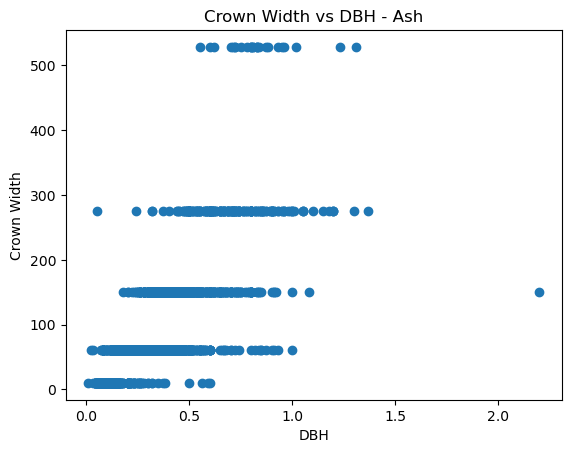

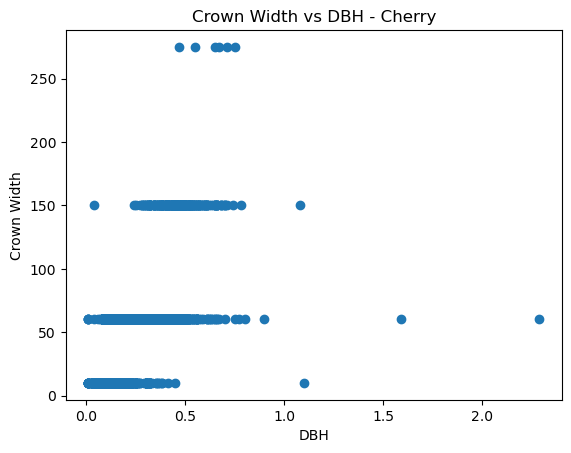

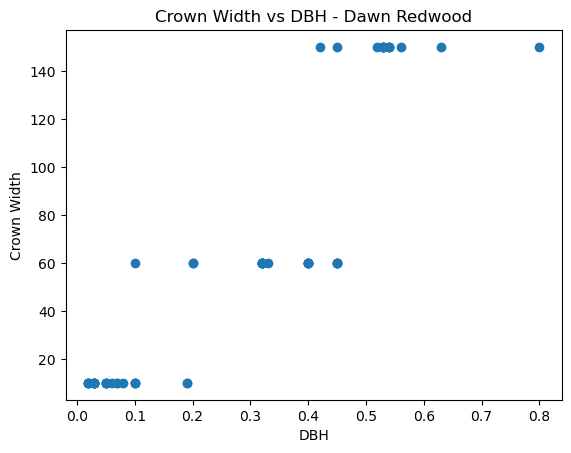

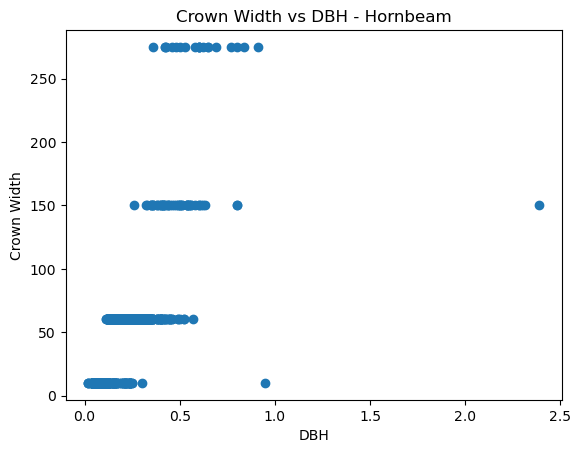

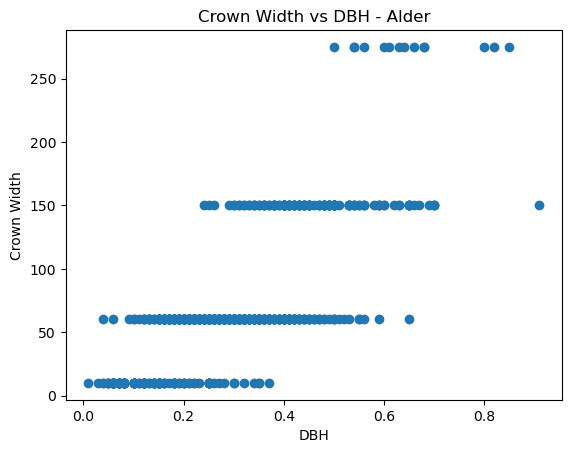

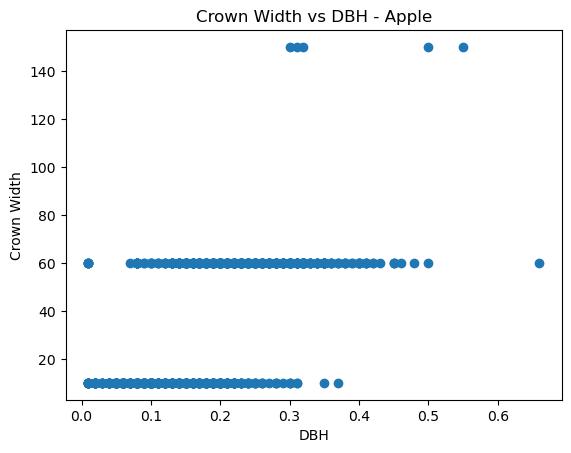

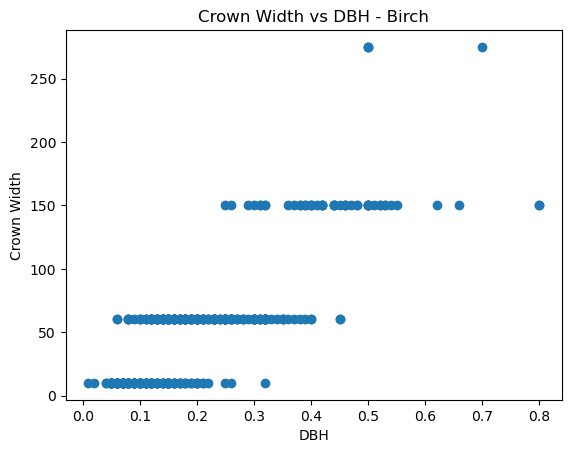

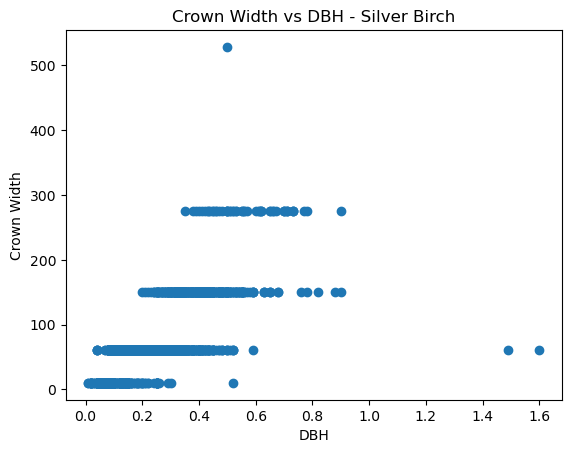

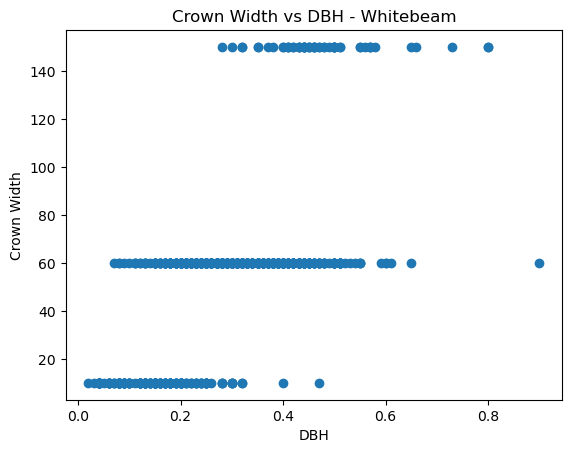

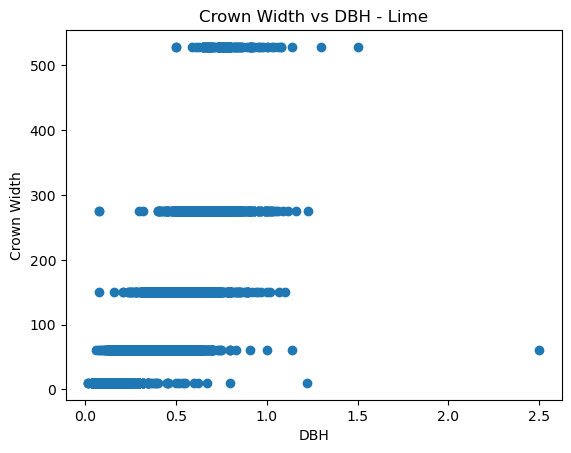

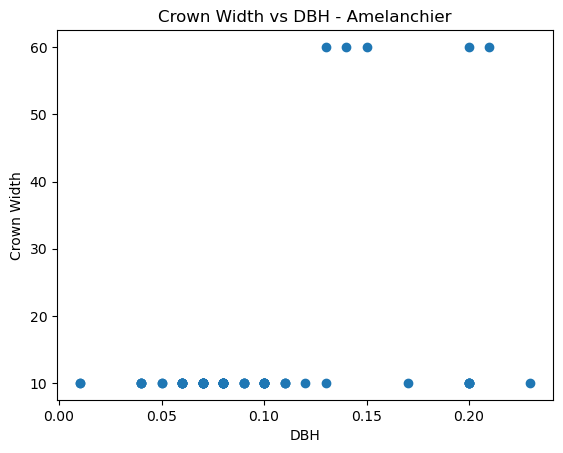

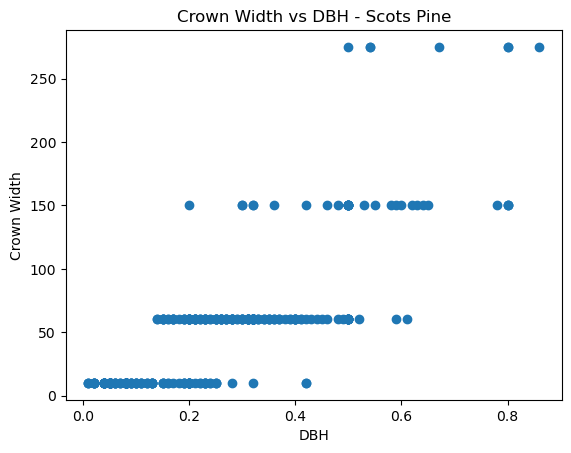

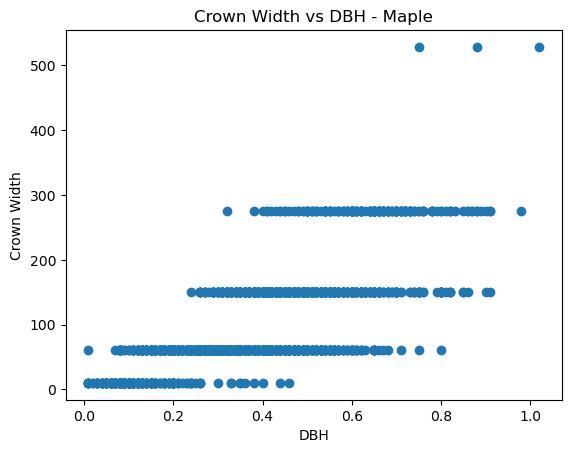

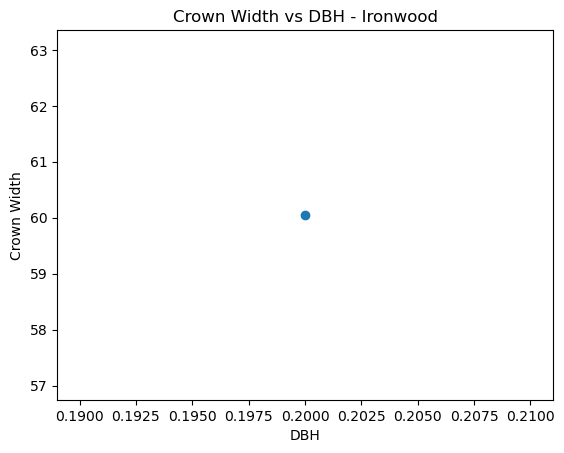

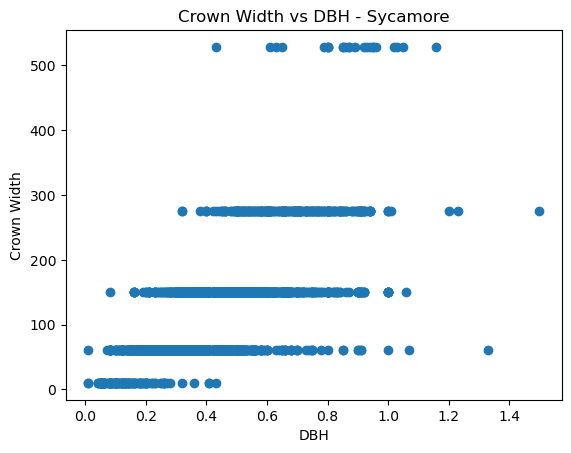

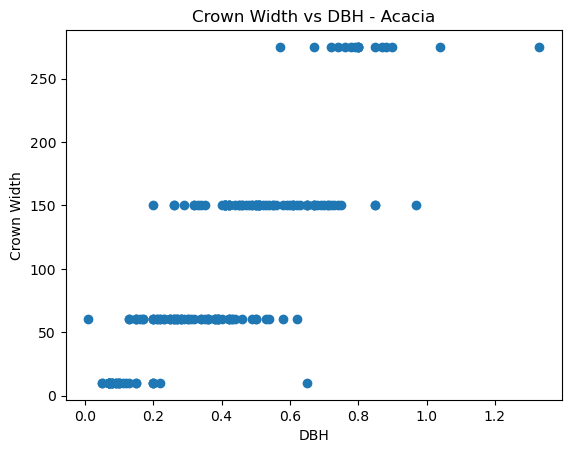

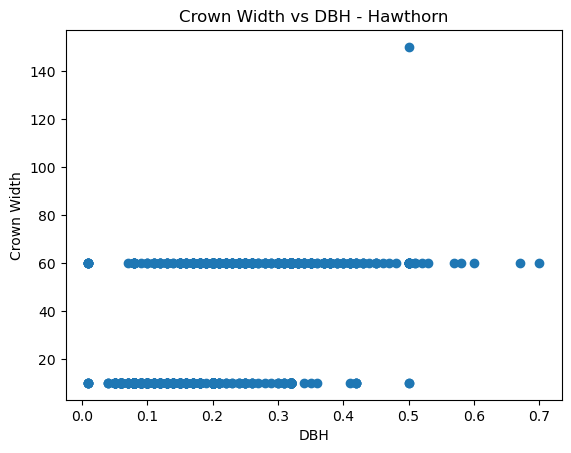

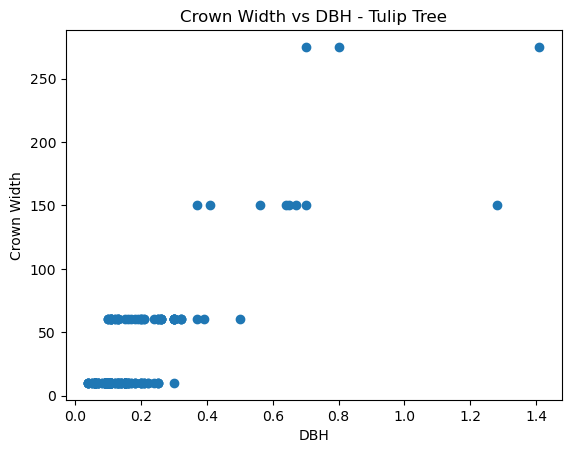

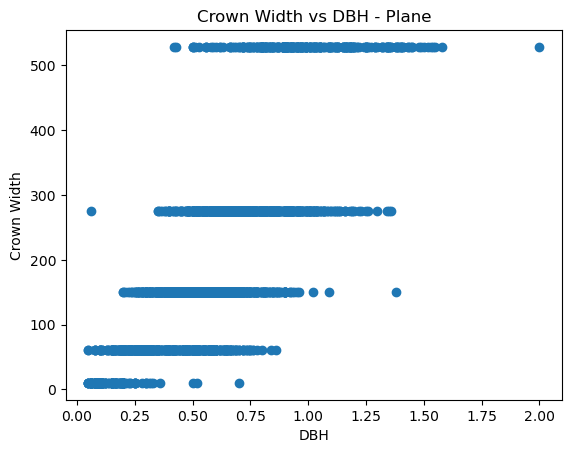

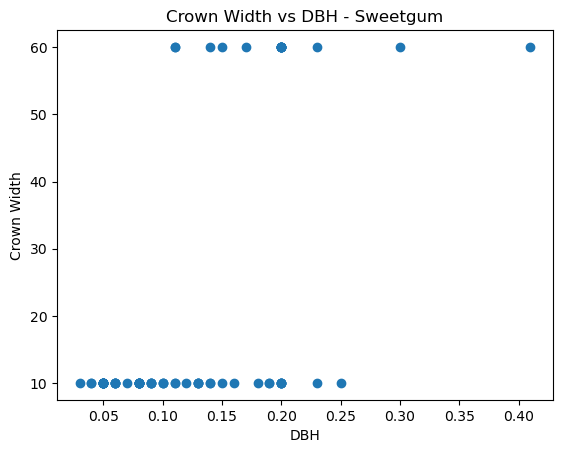

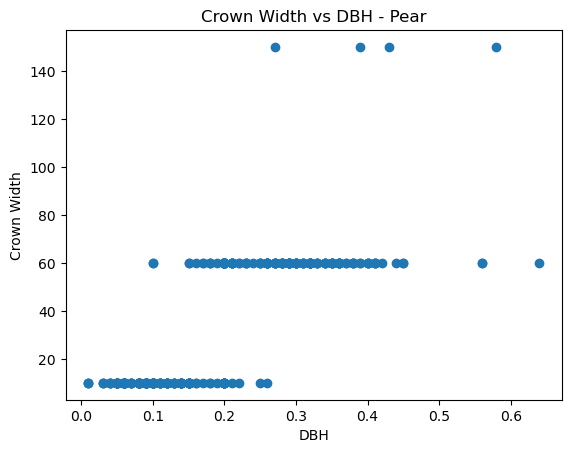

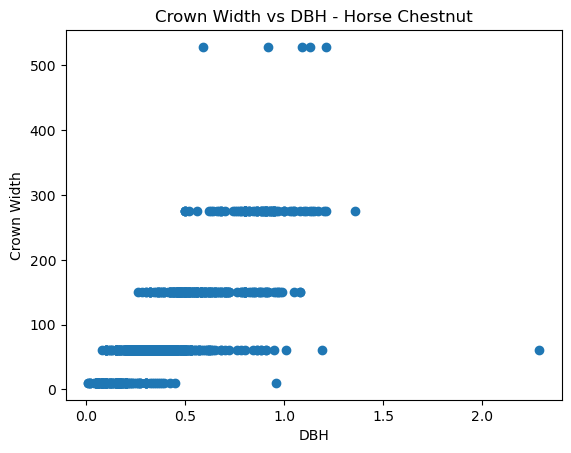

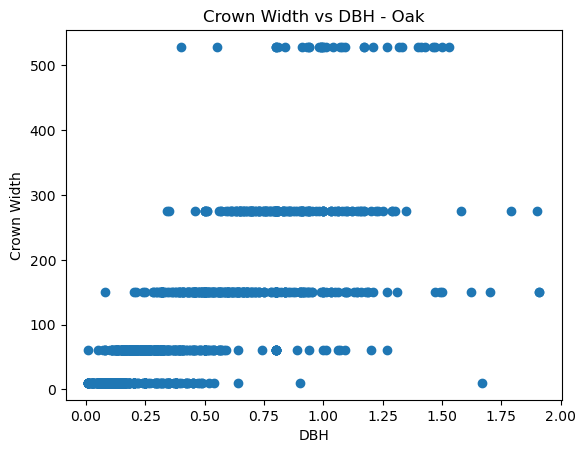

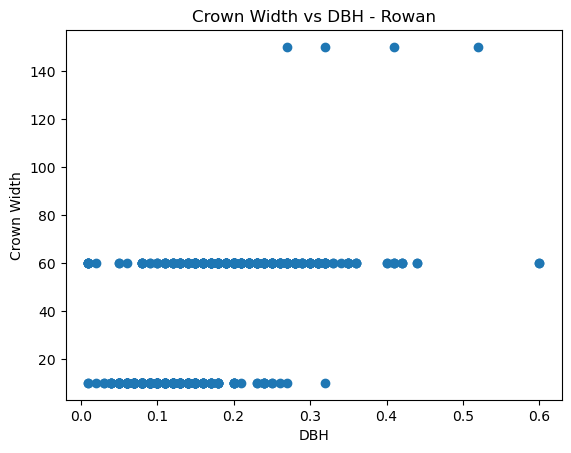

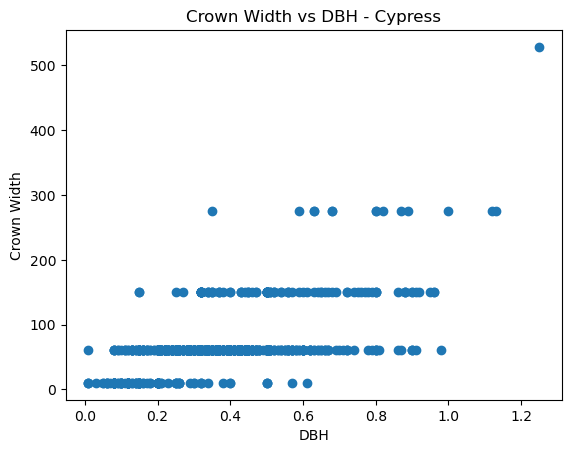

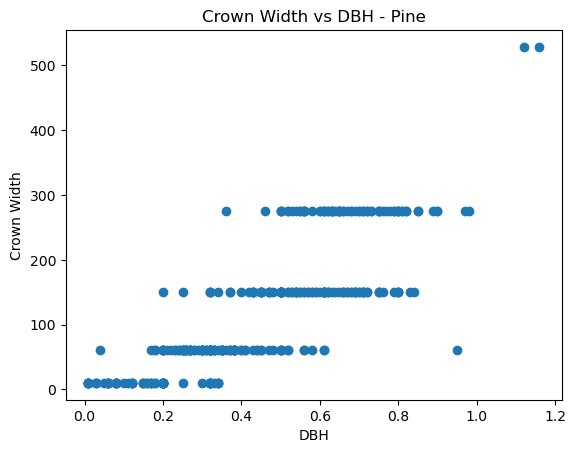

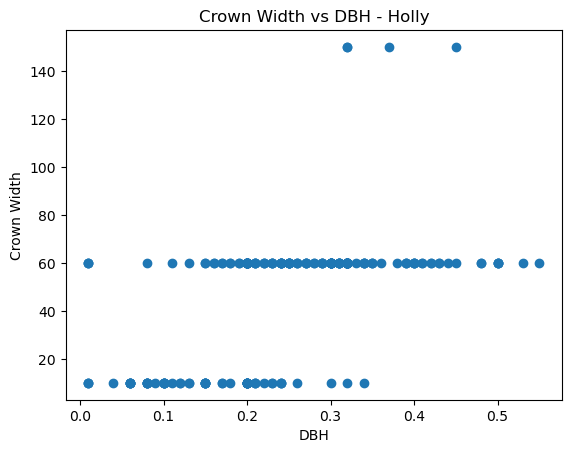

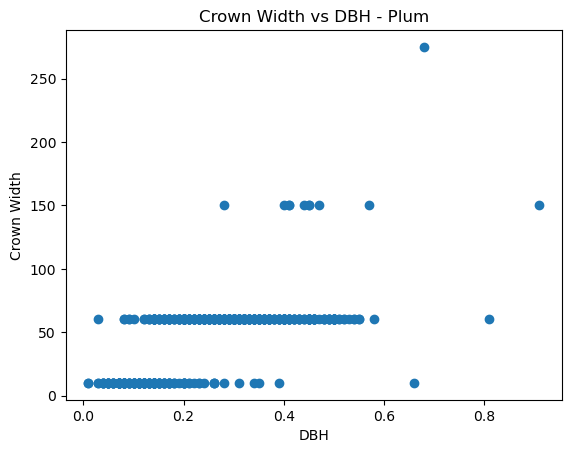

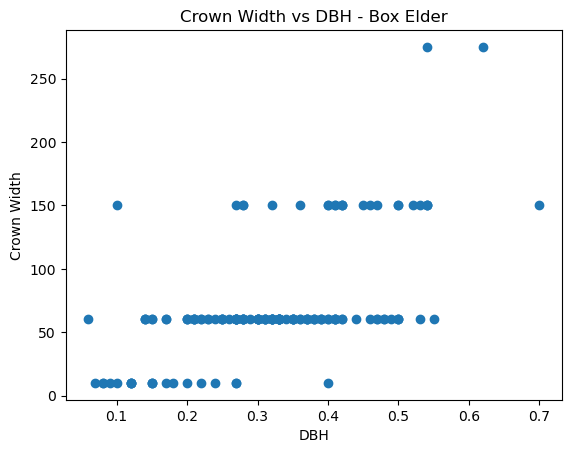

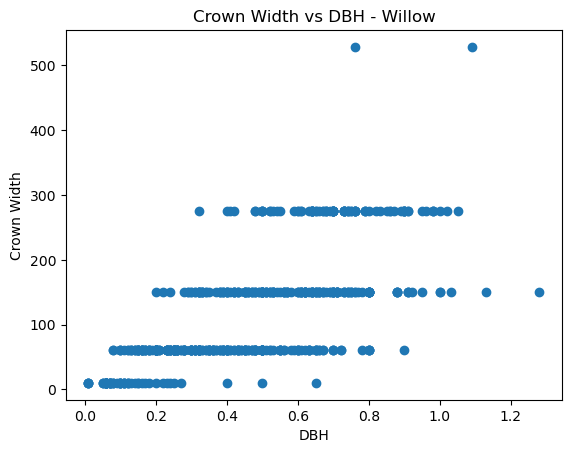

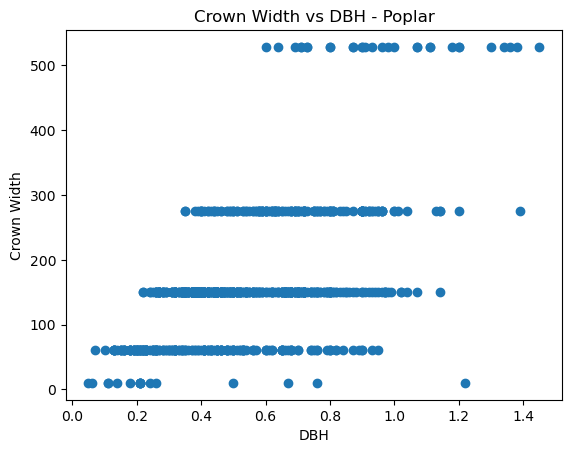

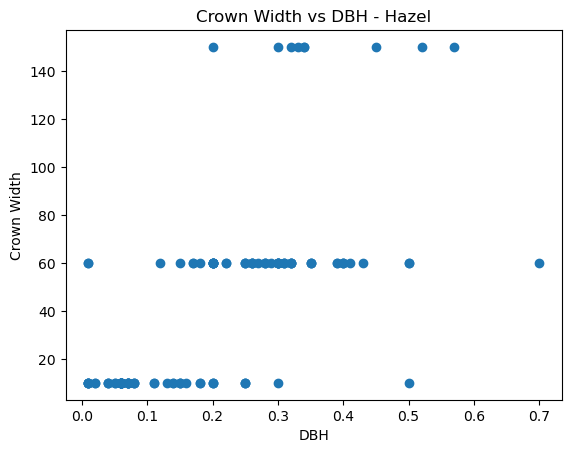

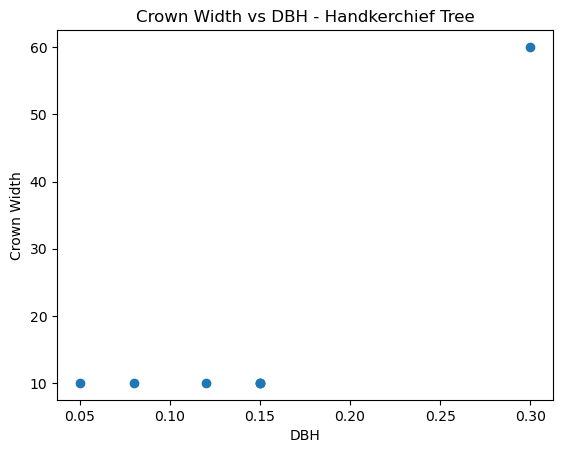

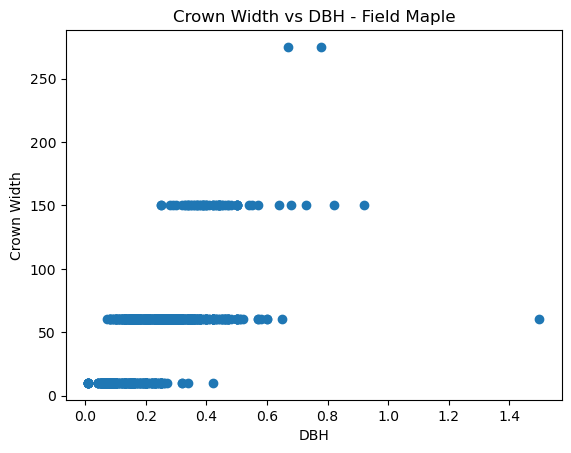

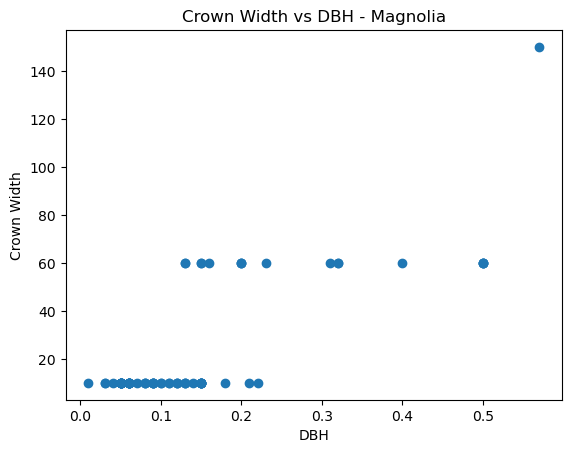

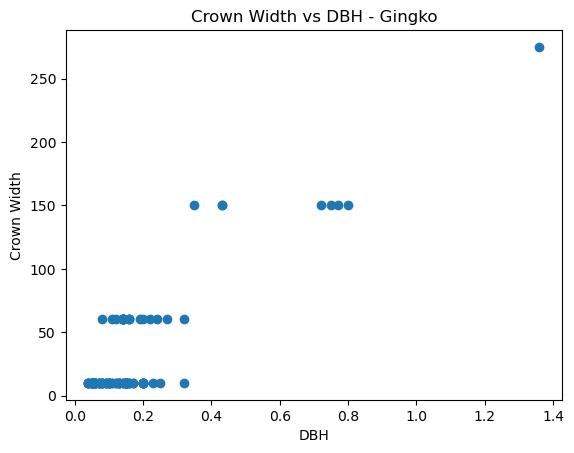

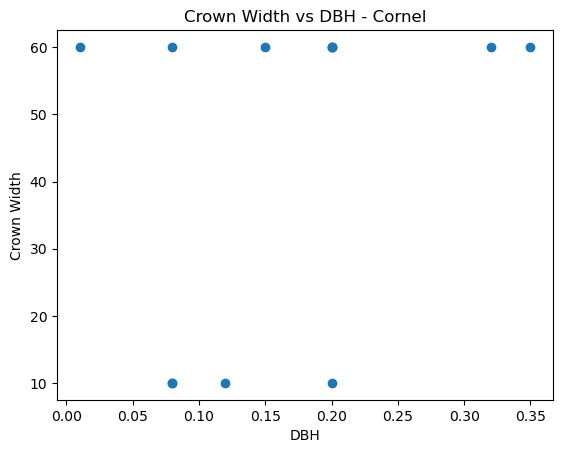

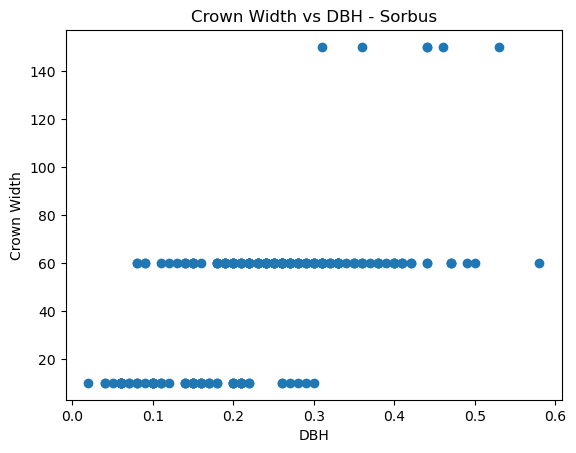

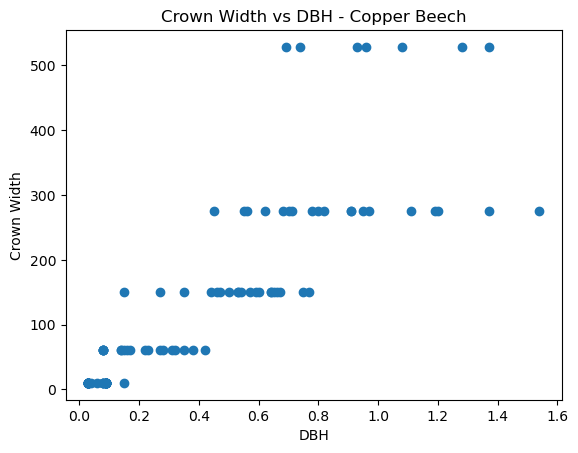

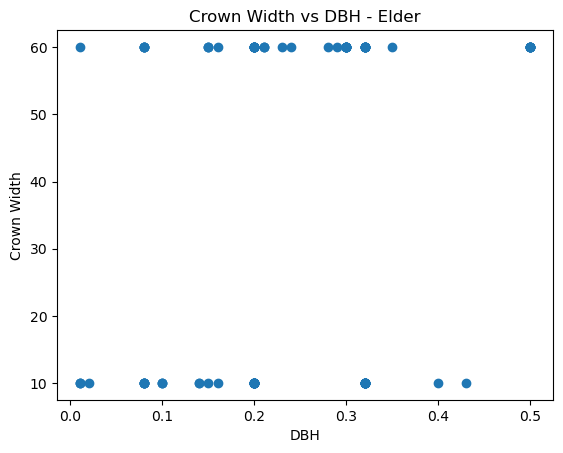

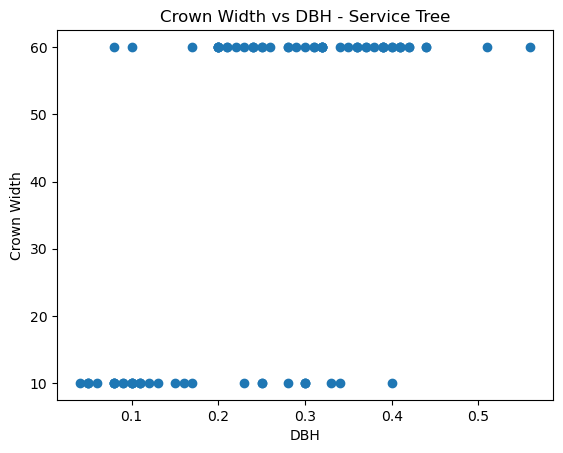

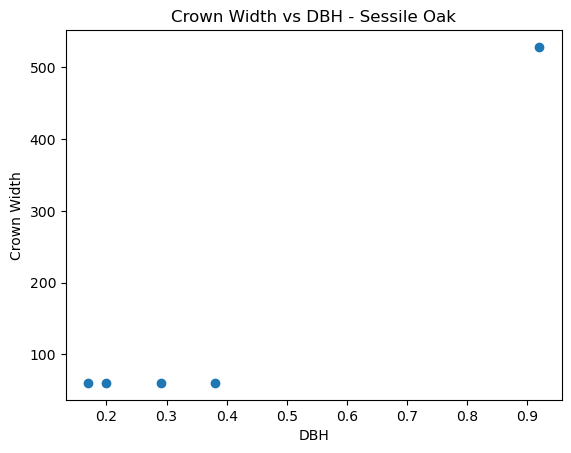

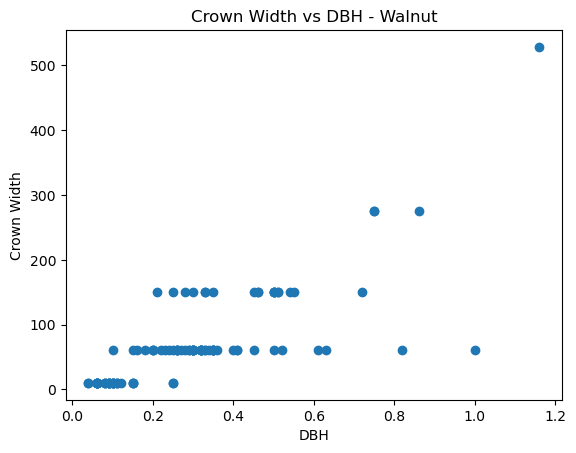

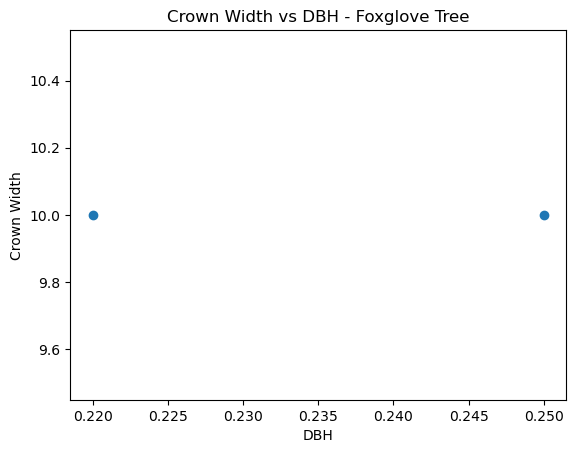

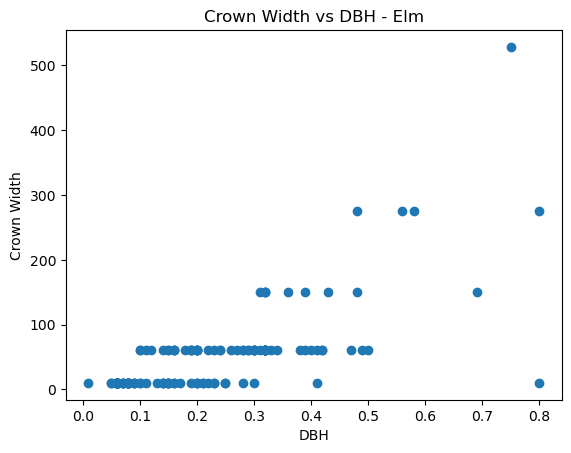

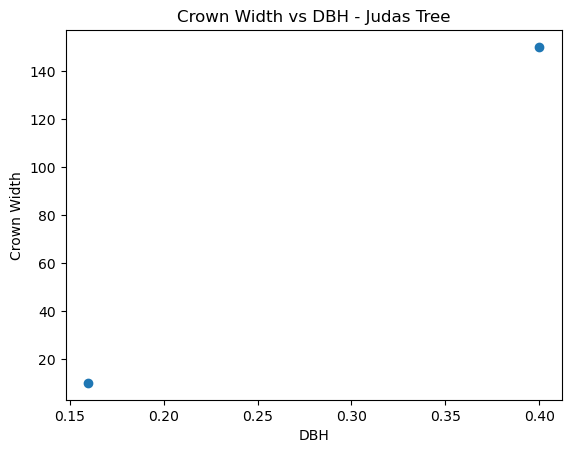

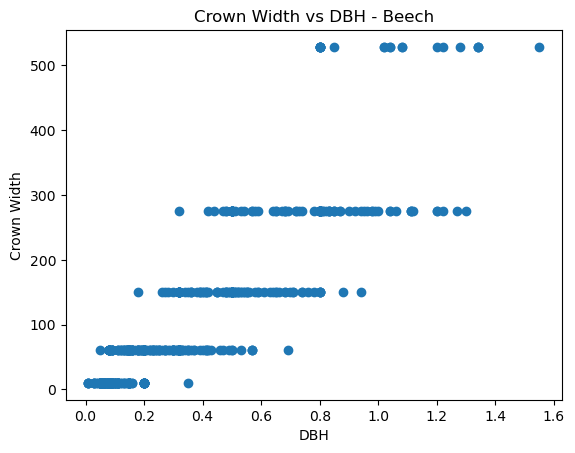

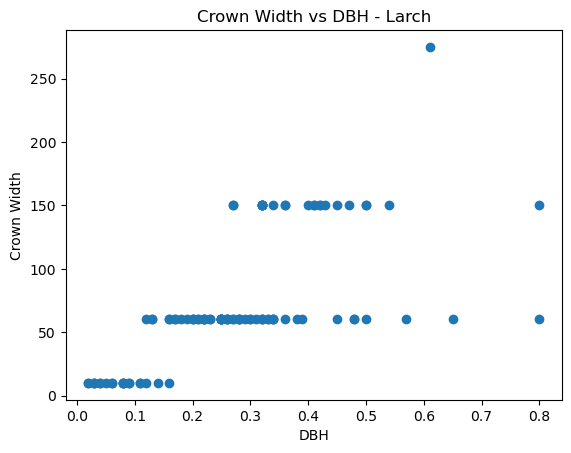

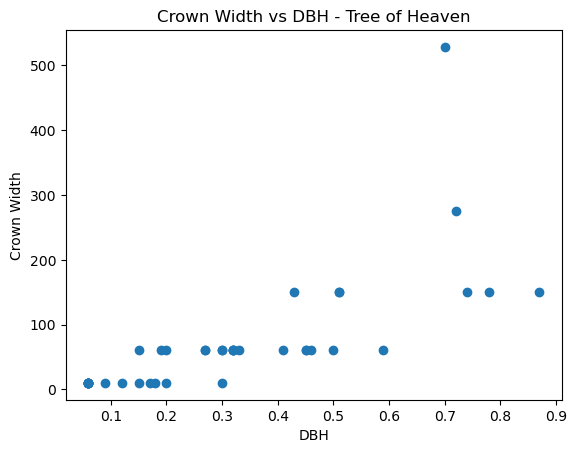

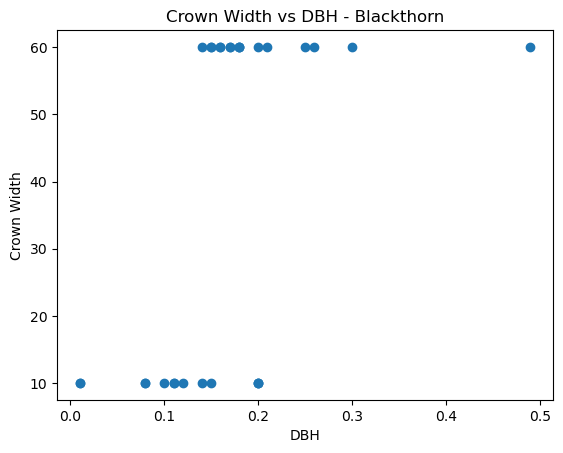

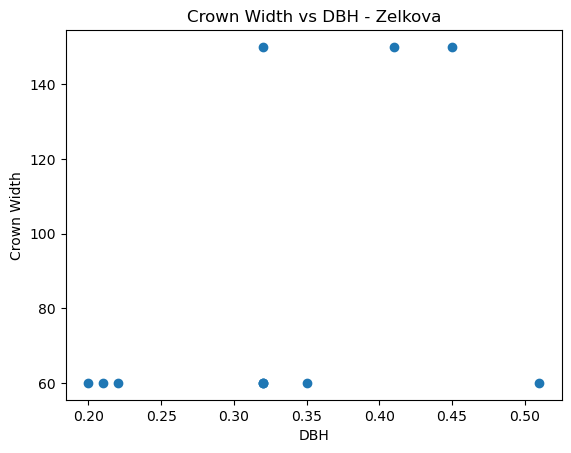

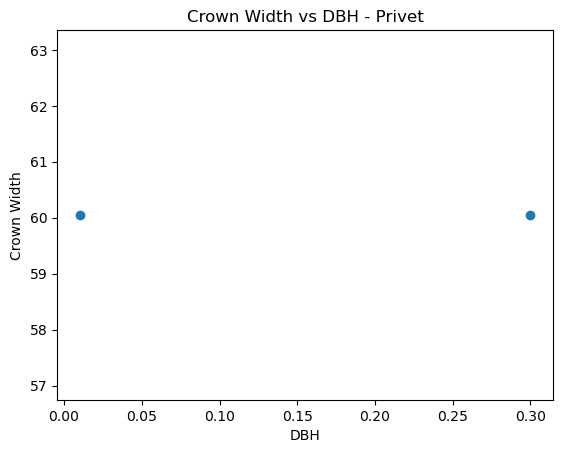

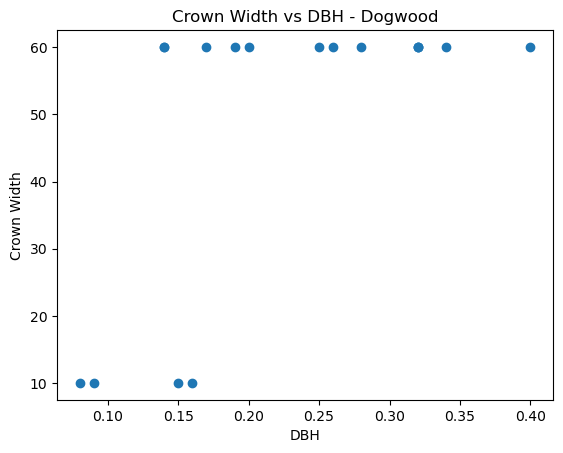

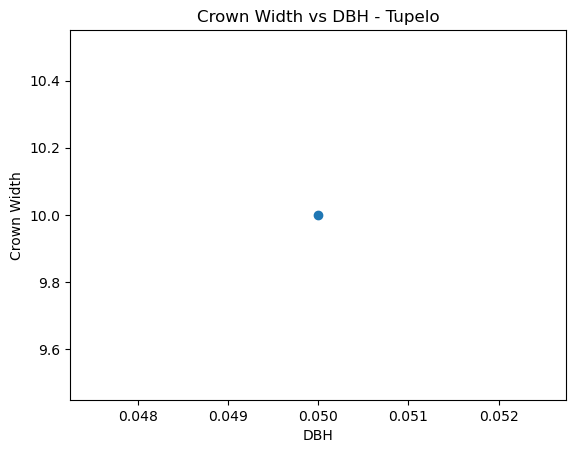

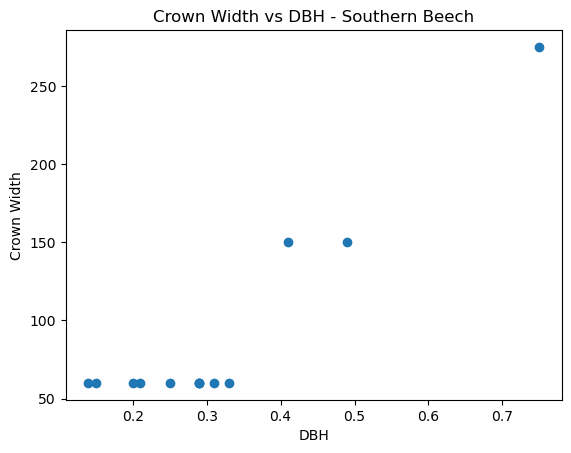

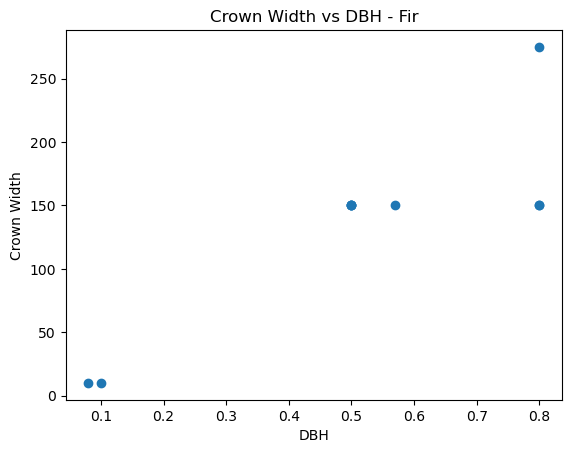

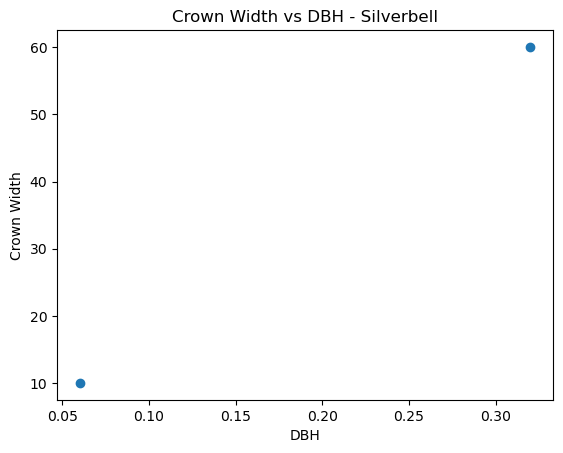

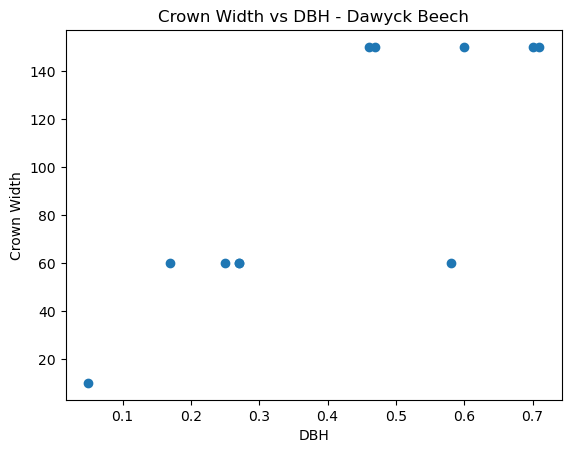

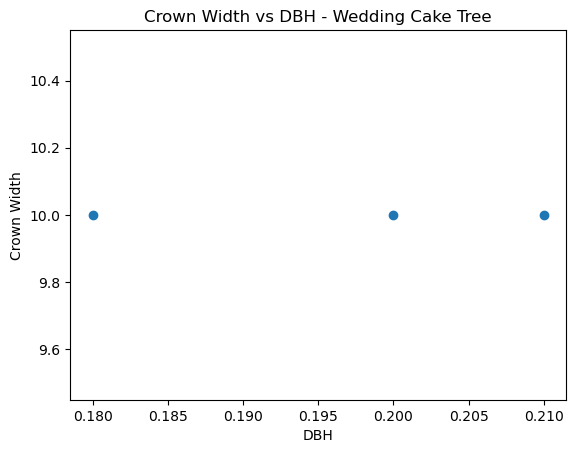

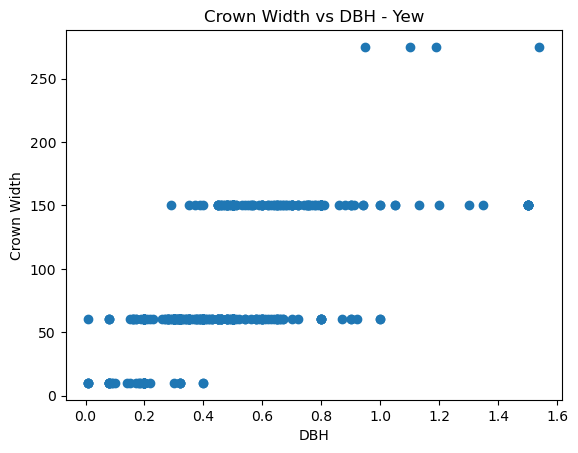

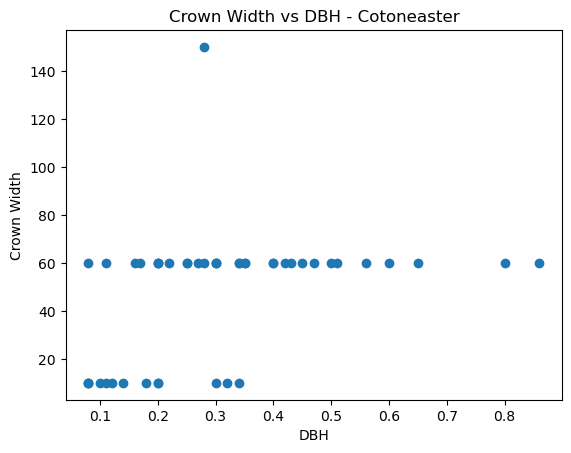

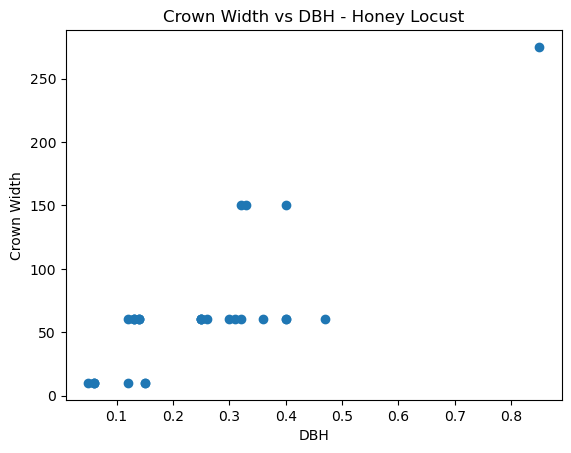

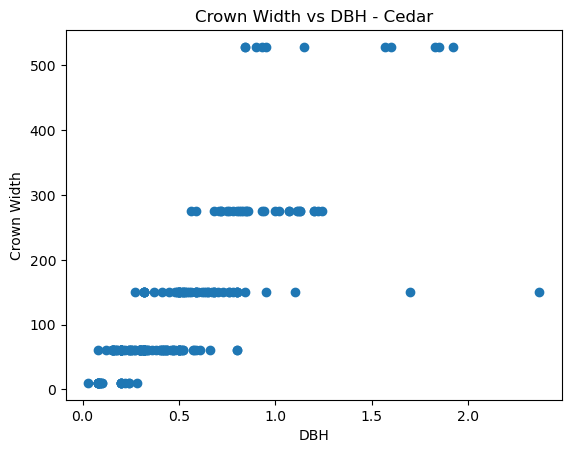

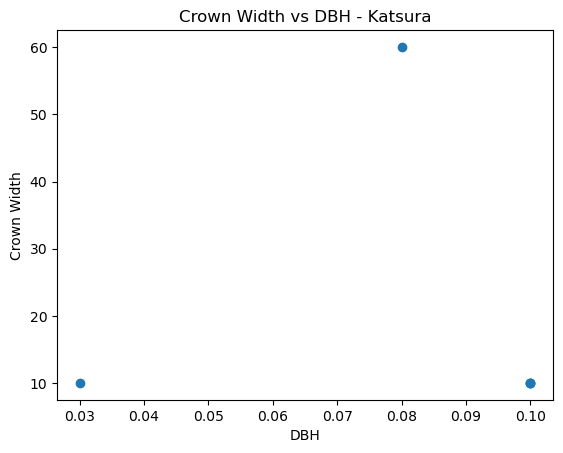

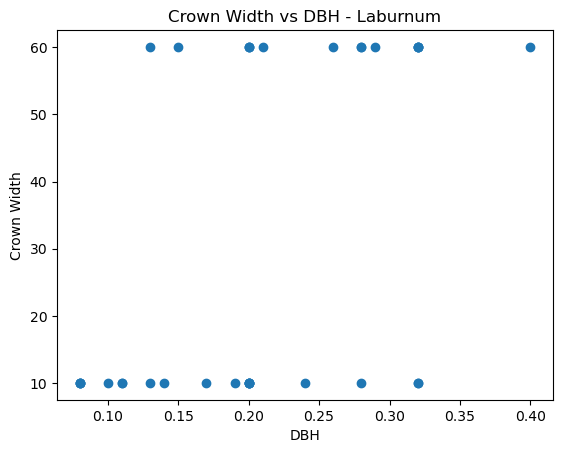

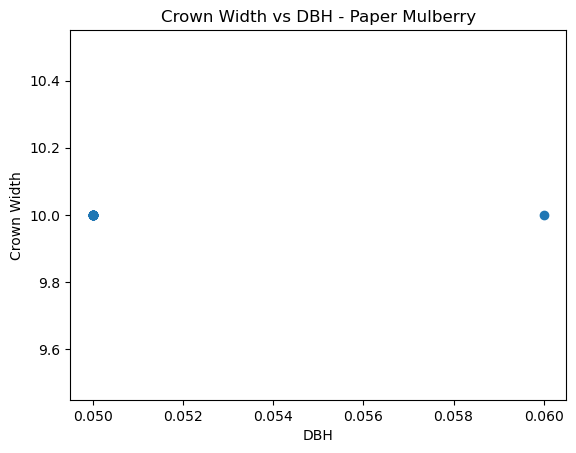

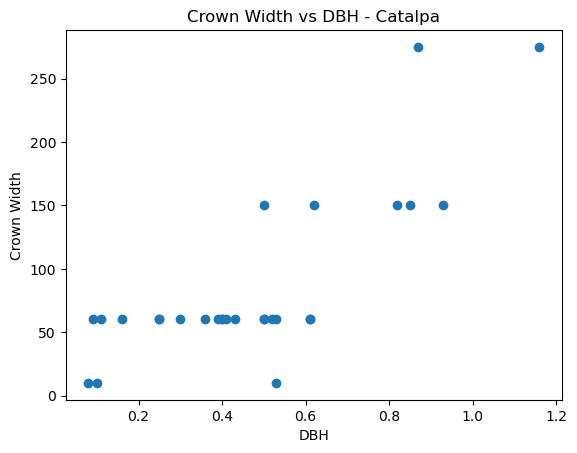

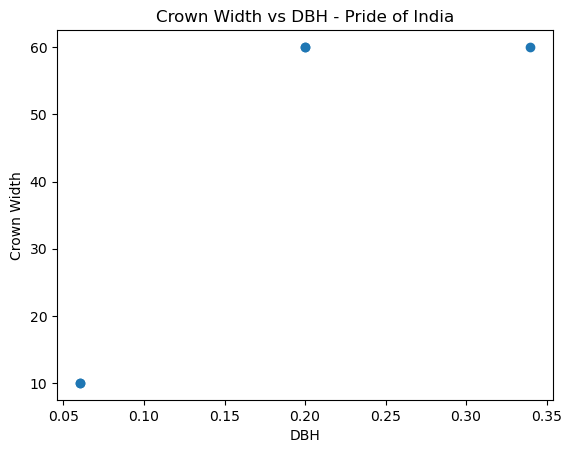

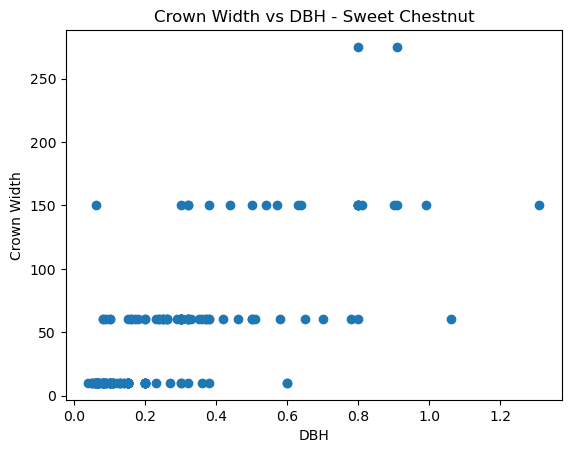

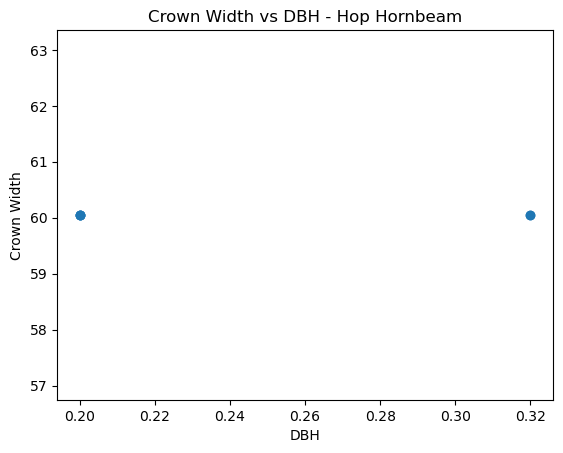

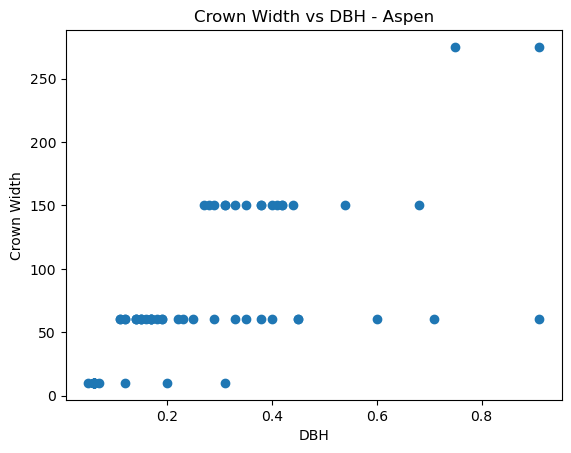

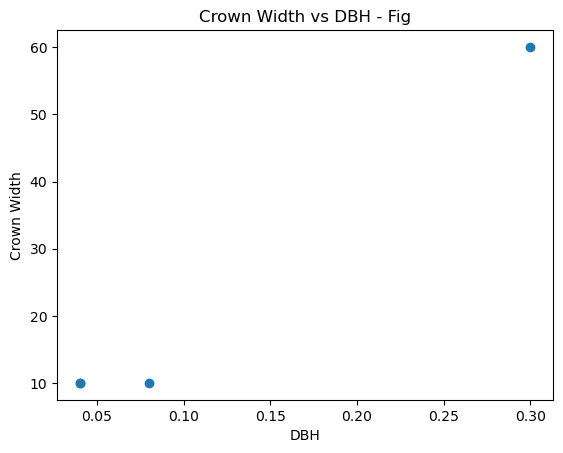

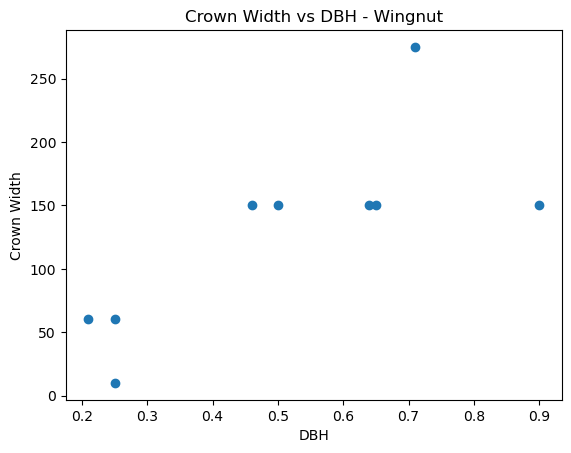

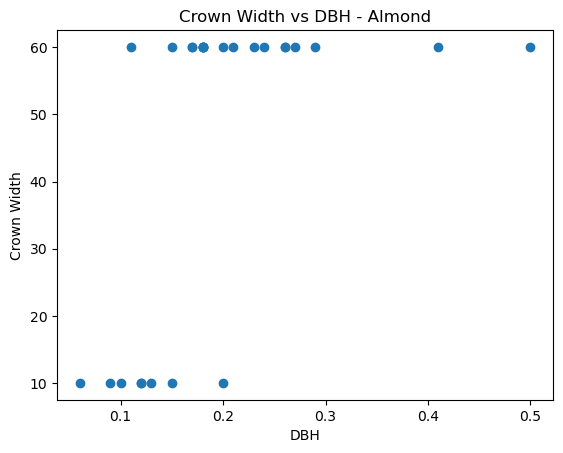

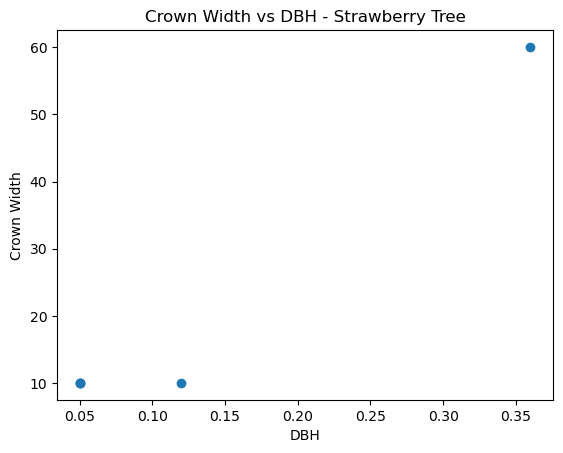

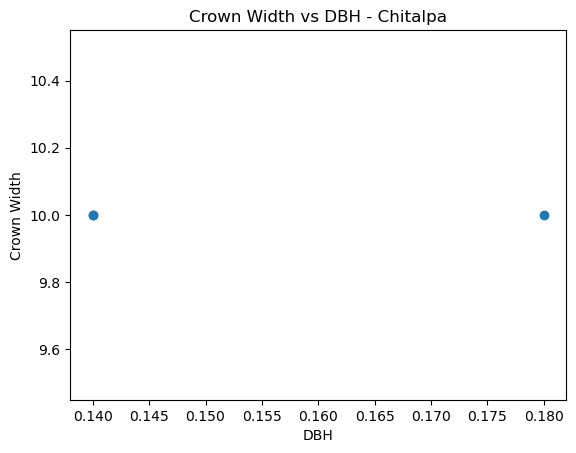

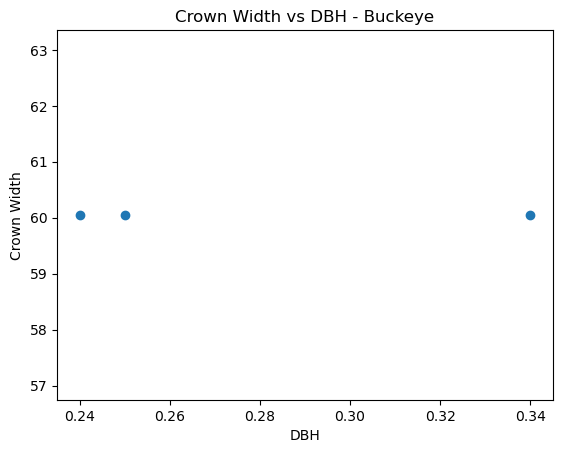

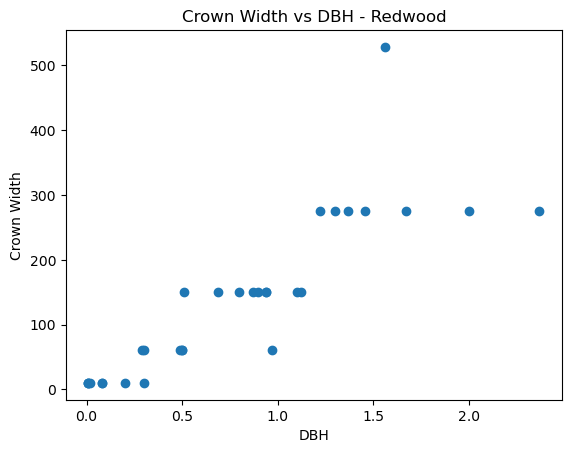

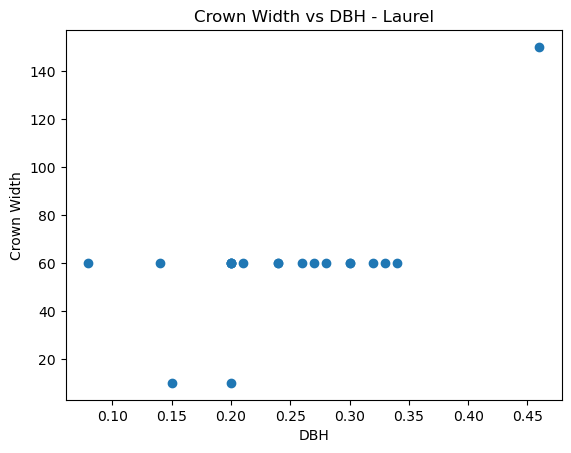

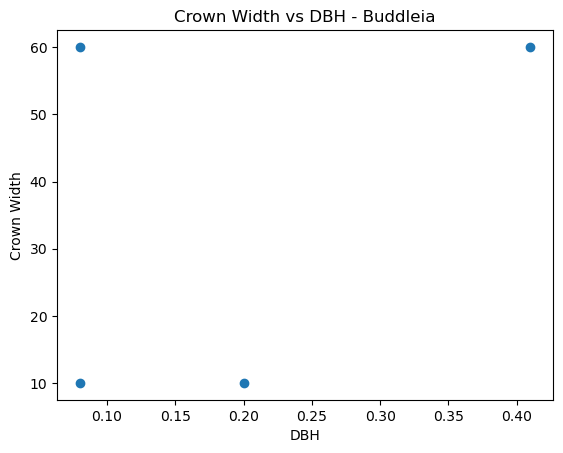

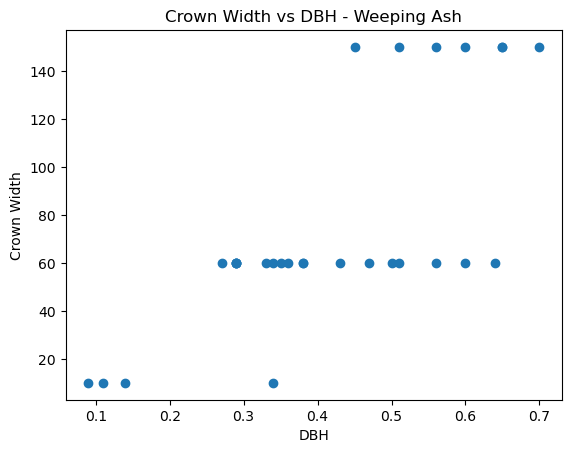

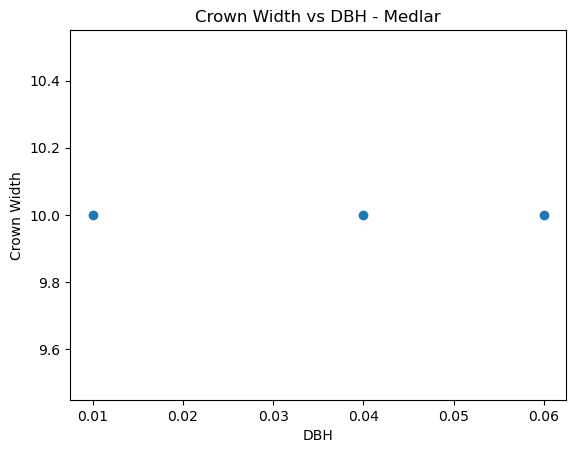

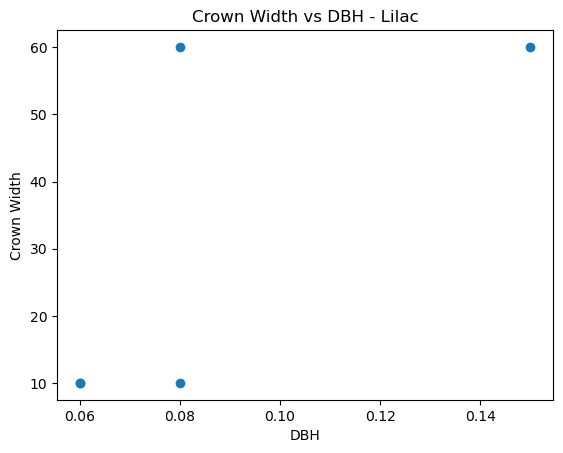

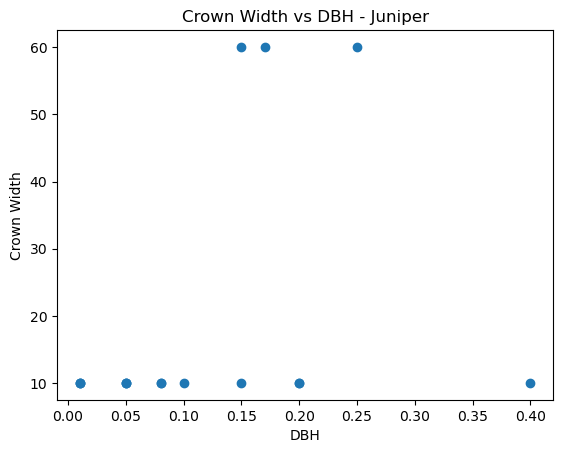

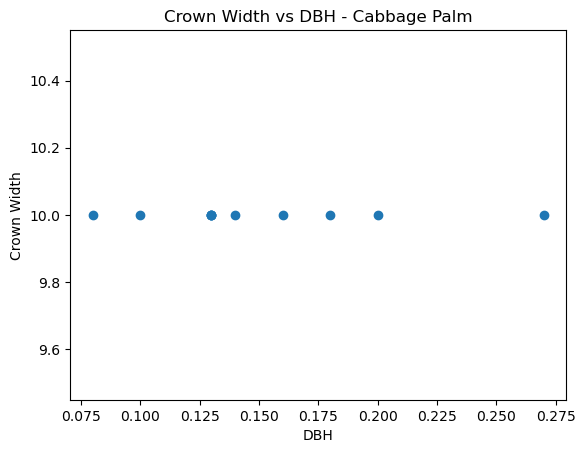

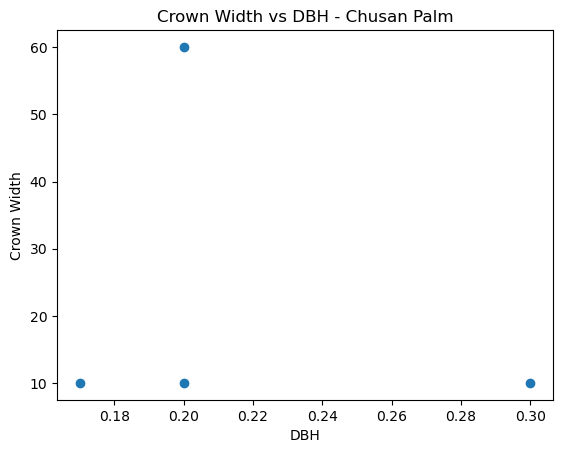

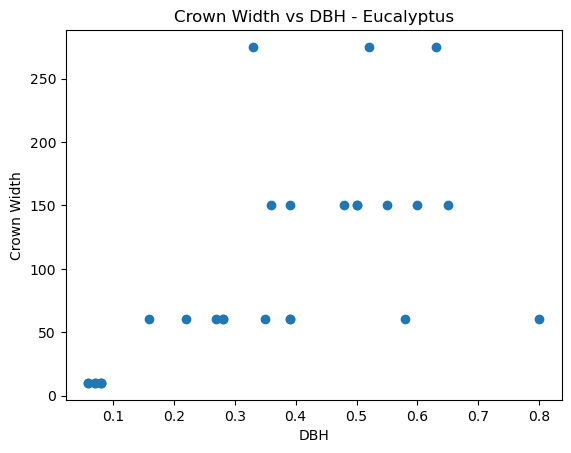

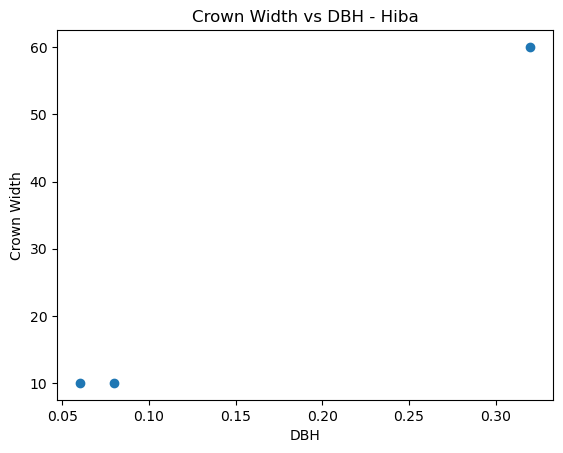

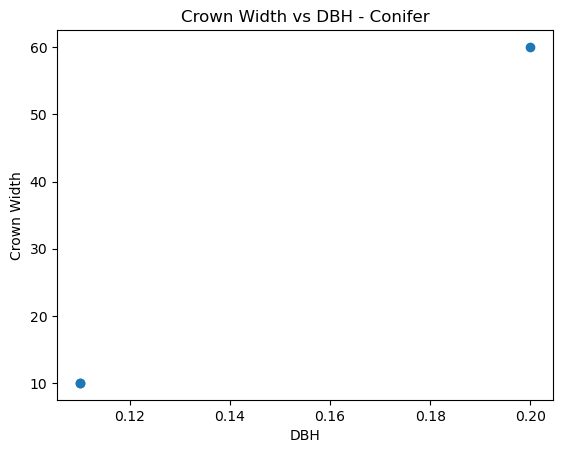

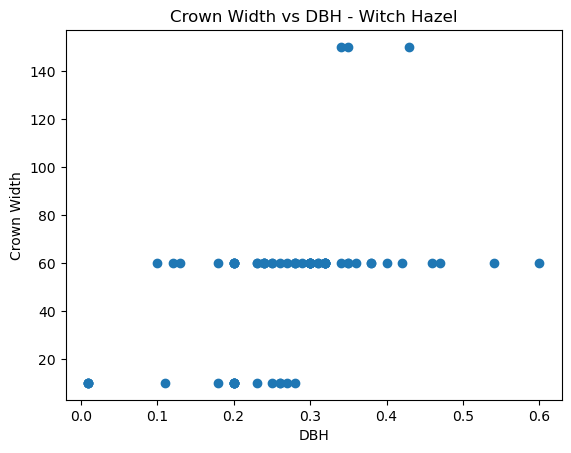

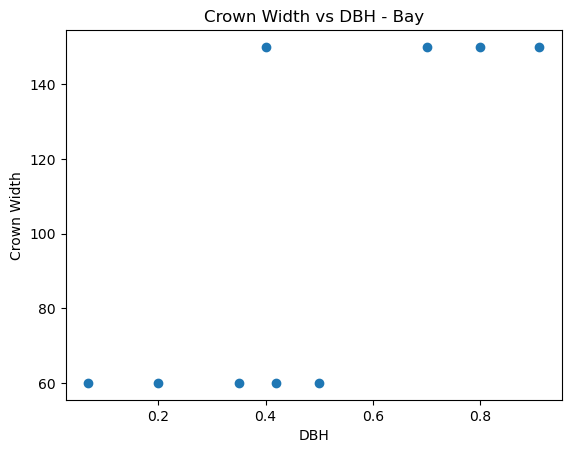

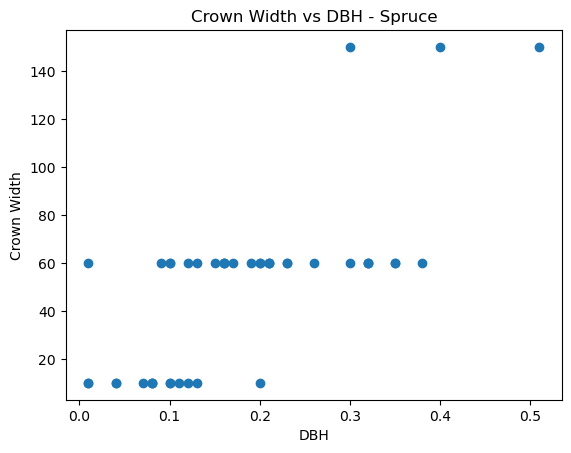

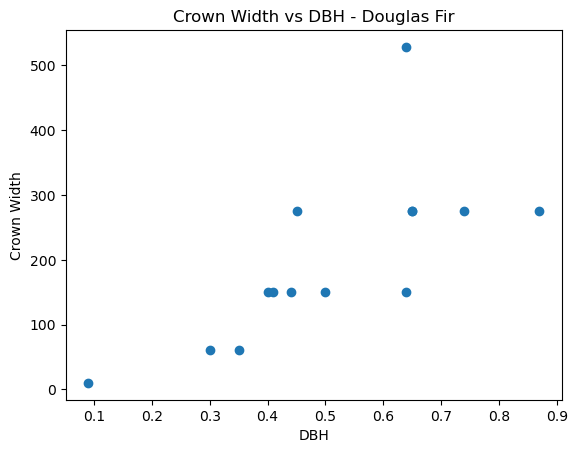

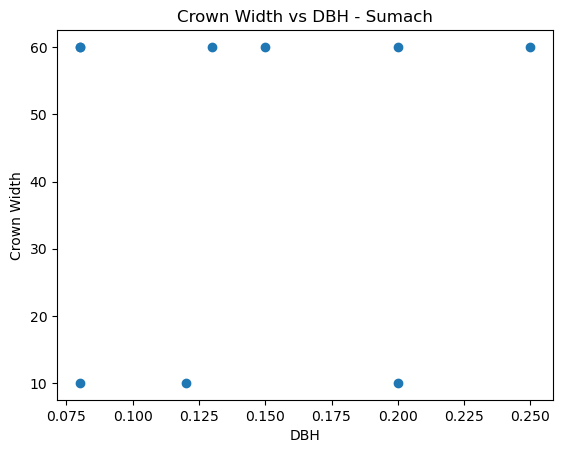

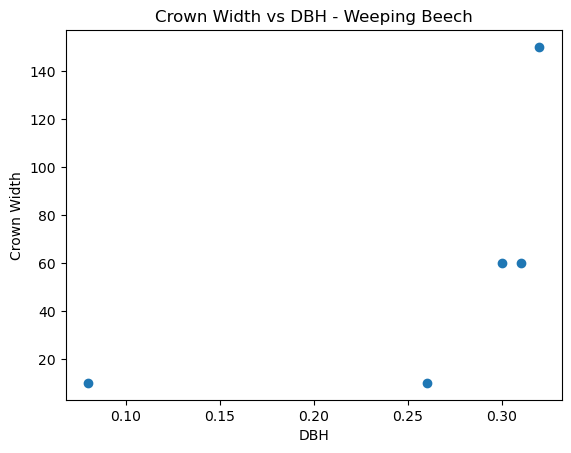

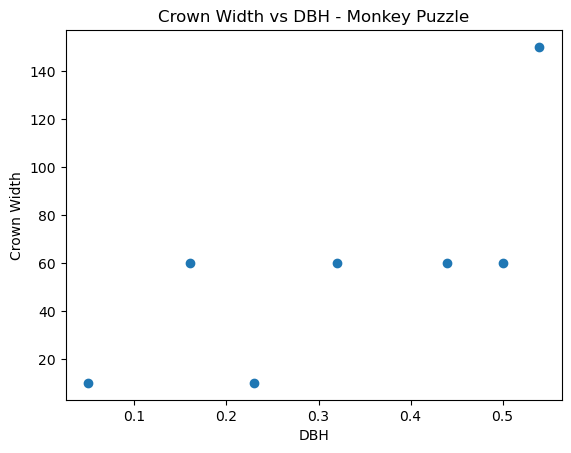

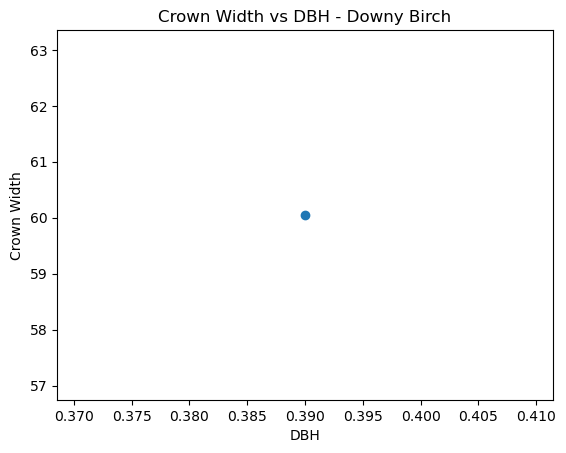

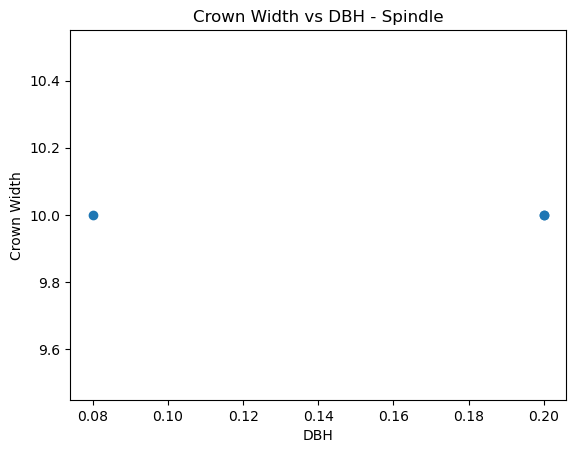

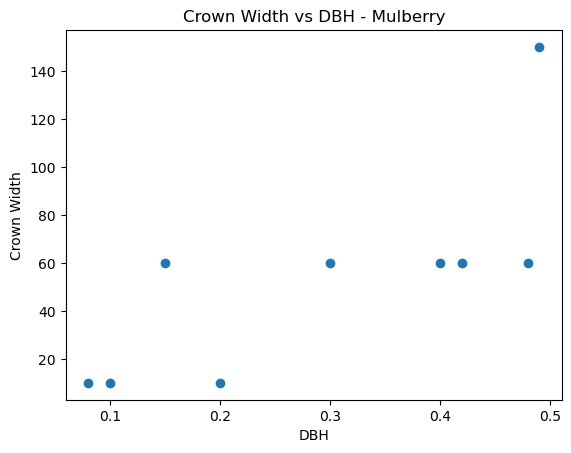

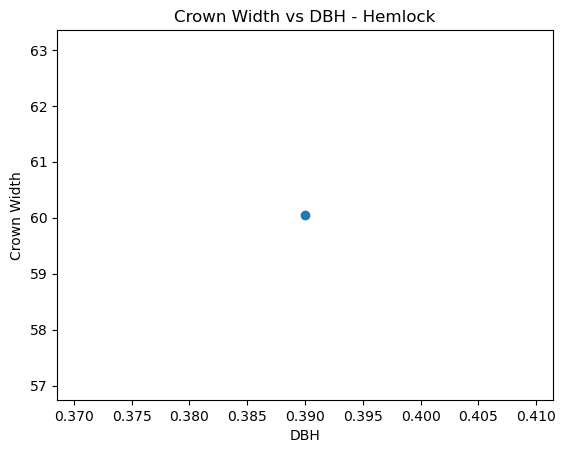

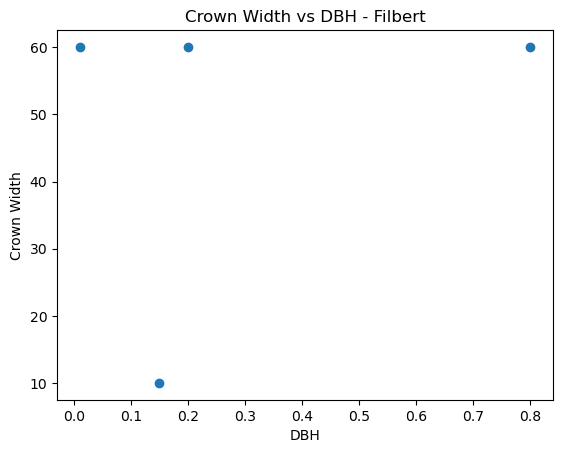

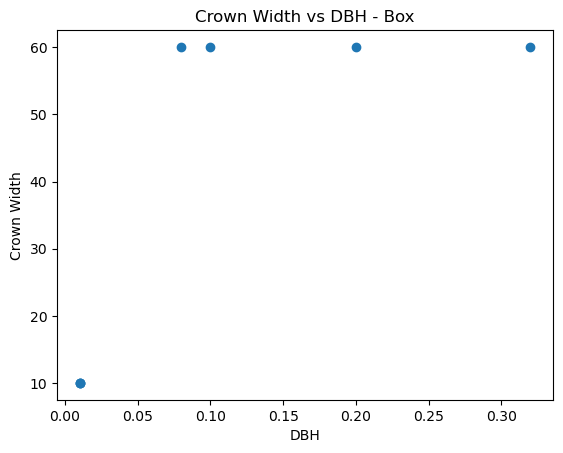

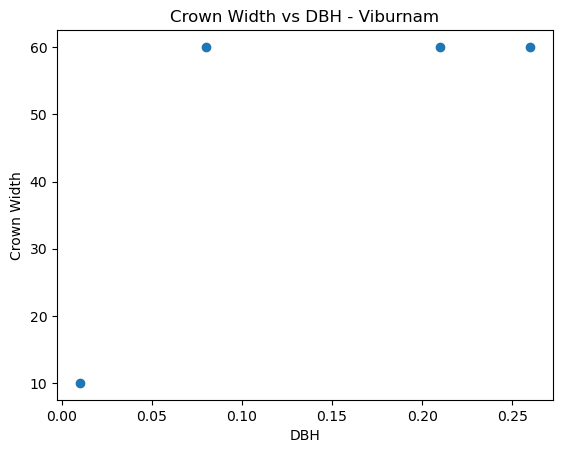

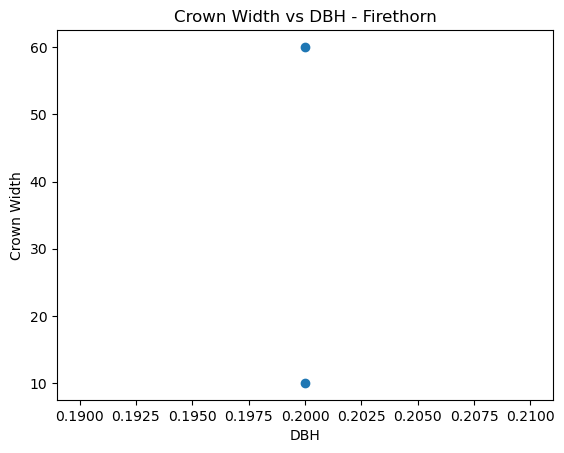

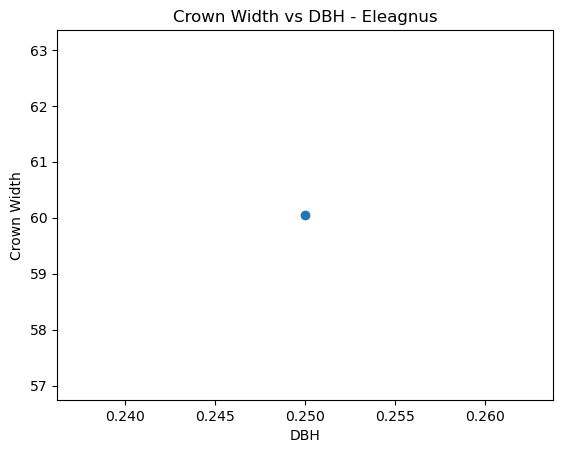

In [29]:
min_points = 1000

import matplotlib.pyplot as plt

species_list = df["COMMON_NAME"].dropna().unique()

for species in species_list:
    df_species = df[df["COMMON_NAME"] == species]
    
    # drop rows where either value is missing
    df_plot = df_species[["DBH", "CROWN_AREA_MIDPOINT"]].dropna()
    
    if df_plot.empty:
        continue
    
    plt.figure()
    plt.scatter(df_plot["DBH"], df_plot["CROWN_AREA_MIDPOINT"])
    
    plt.title(f"Crown Width vs DBH - {species}")
    plt.xlabel("DBH")
    plt.ylabel("Crown Width")
    
    plt.show()
